# Uppgift 11: HR Employee Data Classification

**I föregående kapitel gjordes en EDA på datasetet "hr_employee_data.xlsx". Gör nu ett komplett ML-flöde där den beroende variabeln, y, är `left`. Om den variabeln är 1 så betyder det att den anställde har lämnat företaget och om den är 0 så betyder det att den anställde inte har lämnat företaget, det vill säga jobbar kvar.**

## Lösning

In [1]:
# Imports - endast det som behövs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sätt stil för plots
plt.style.use('default')
sns.set_palette("husl")

### Steg 1: Ladda och utforska data

In [2]:
# Ladda datasetet
df = pd.read_excel('hr_employee_data.xlsx')

print("Dataset information:")
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print(f"Kolumner: {list(df.columns)}")

print("\nFörsta 5 rader:")
print(df.head())

print("\nDatatyper:")
print(df.dtypes)

print("\nSaknade värden:")
print(df.isnull().sum())

Dataset information:
Antal rader: 14999
Antal kolumner: 11
Kolumner: ['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Första 5 rader:
     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5

### Steg 2: Analysera målvariabeln

Fördelning av målvariabeln 'left':
left
0    11428
1     3571
Name: count, dtype: int64

Procentuell fördelning:
left
0    76.191746
1    23.808254
Name: proportion, dtype: float64


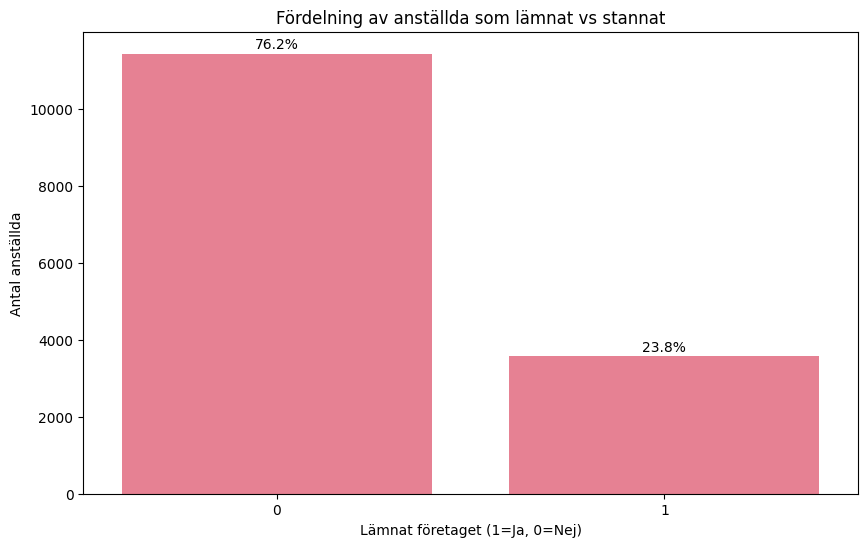

In [3]:
# Analysera målvariabeln 'left'
print("Fördelning av målvariabeln 'left':")
print(df['left'].value_counts())
print(f"\nProcentuell fördelning:")
print(df['left'].value_counts(normalize=True) * 100)

# Visualisera fördelningen
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='left')
plt.title('Fördelning av anställda som lämnat vs stannat')
plt.xlabel('Lämnat företaget (1=Ja, 0=Nej)')
plt.ylabel('Antal anställda')

# Lägg till procenttal på bars
total = len(df)
for i, v in enumerate(df['left'].value_counts()):
    plt.text(i, v + 50, f'{v/total*100:.1f}%', ha='center', va='bottom')

plt.show()

### Steg 3: EDA - Utforska relationer med målvariabeln 

Numeriska variabler: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


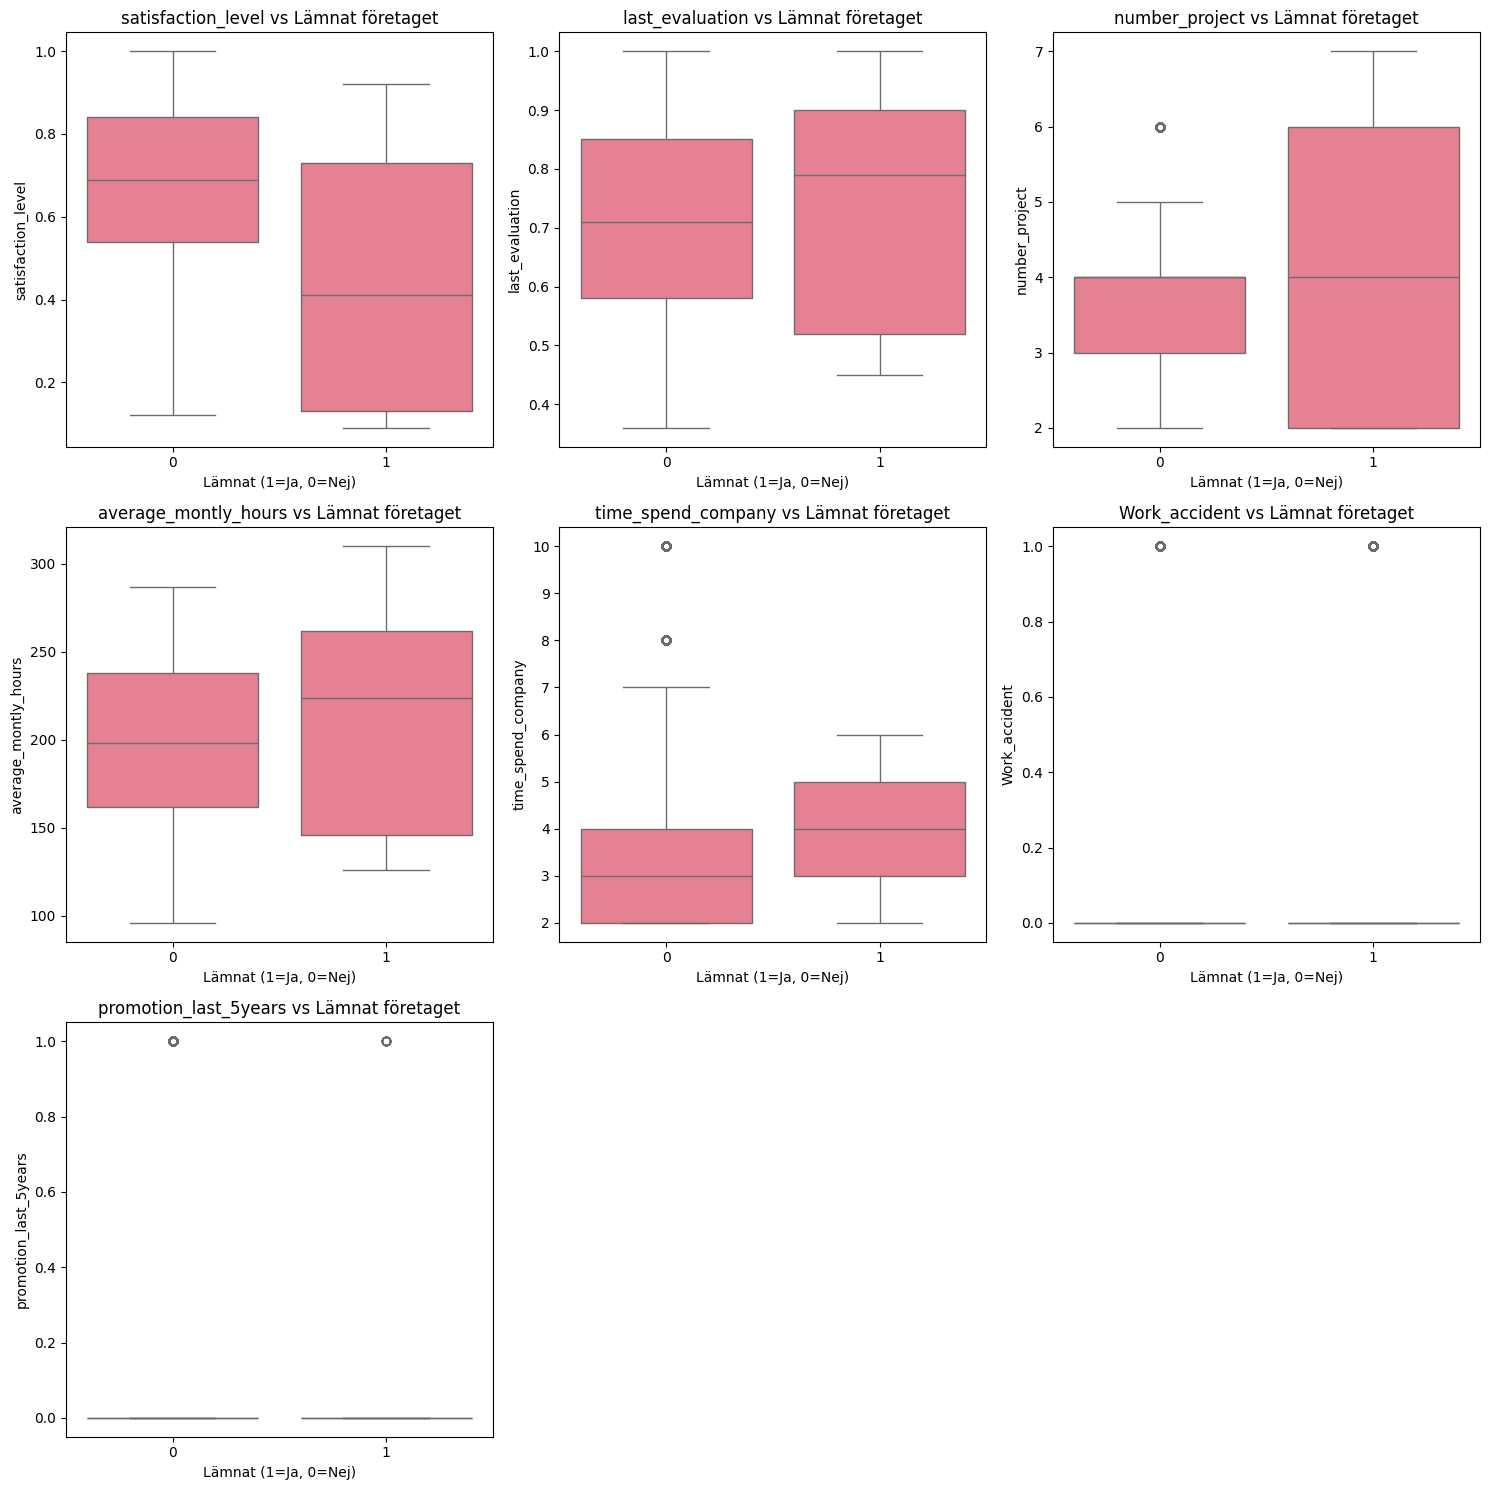

In [4]:
# Analysera numeriska variabler
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('left')  # Ta bort målvariabeln

print("Numeriska variabler:", numeric_cols)

# OPTIMERING: Skapa mindre, snabbare boxplots
n_numeric = len(numeric_cols)
n_cols = 3
n_rows = (n_numeric + n_cols - 1) // n_cols  # Avrunda uppåt

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        # Använd seaborn för snabbare plotting
        sns.boxplot(data=df, x='left', y=col, ax=axes[i])
        axes[i].set_title(f'{col} vs Lämnat företaget')
        axes[i].set_xlabel('Lämnat (1=Ja, 0=Nej)')

# Dölj tomma subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Kategoriska variabler: ['Emp_Id', 'Department', 'salary']
Variabler att plotta: ['Department', 'salary']


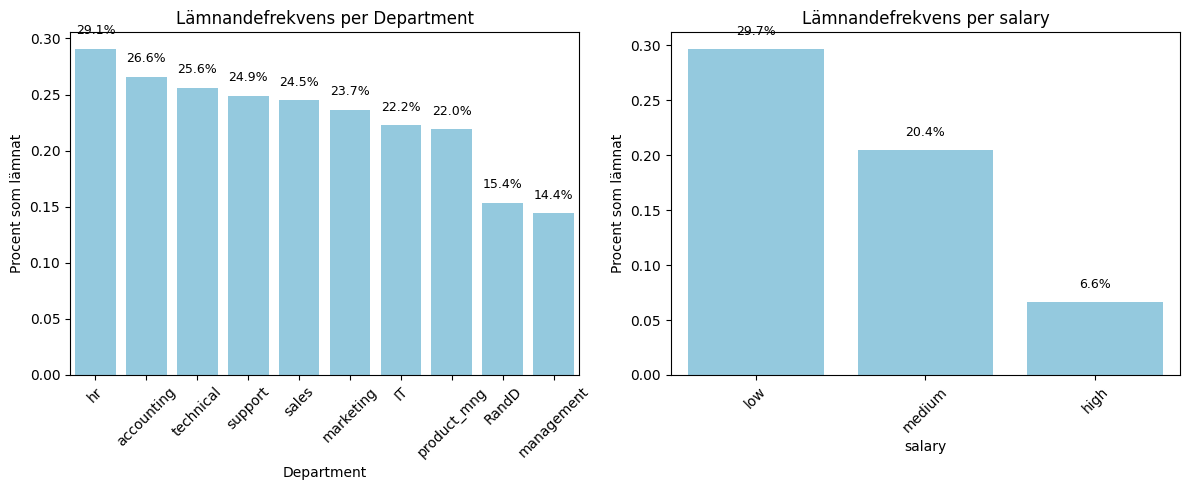

In [5]:
# Analysera kategoriska variabler (OPTIMERAD - snabbare)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Kategoriska variabler:", categorical_cols)

# OPTIMERING: Använd bara de viktigaste kategoriska variablerna (exkludera Emp_Id)
plot_categorical_cols = [col for col in categorical_cols if col != 'Emp_Id']
print("Variabler att plotta:", plot_categorical_cols)

# Skapa en enklare visualisering - bara 2 variabler i en rad
n_cat = len(plot_categorical_cols)
if n_cat > 0:
    fig, axes = plt.subplots(1, n_cat, figsize=(6*n_cat, 5))
    if n_cat == 1:
        axes = [axes]
    
    for i, col in enumerate(plot_categorical_cols):
        # Beräkna procent som lämnat för varje kategori
        turnover_rate = df.groupby(col)['left'].mean().sort_values(ascending=False)
        
        # Använd seaborn för snabbare plotting
        sns.barplot(x=turnover_rate.index, y=turnover_rate.values, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Lämnandefrekvens per {col}')
        axes[i].set_ylabel('Procent som lämnat')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Lägg till procenttal på bars (bara för de viktigaste)
        for j, v in enumerate(turnover_rate.values):
            axes[i].text(j, v + 0.01, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("Inga kategoriska variabler att plotta")

### Steg 4: Förbereda data för modellering 

In [6]:
# Separera features och target (FIXAD: exkluderar Emp_Id)
X = df.drop(['left', 'Emp_Id'], axis=1)  # Exkludera både target och Emp_Id
y = df['left']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Identifiera numeriska och kategoriska kolumner
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeriska features ({len(numeric_features)}): {numeric_features}")
print(f"Kategoriska features ({len(categorical_features)}): {categorical_features}")
print("\nOBS: Emp_Id exkluderades eftersom den är unik för varje anställd och inte användbar för prediktion")

Features shape: (14999, 9)
Target shape: (14999,)

Numeriska features (7): ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']
Kategoriska features (2): ['Department', 'salary']

OBS: Emp_Id exkluderades eftersom den är unik för varje anställd och inte användbar för prediktion


In [7]:
# Dela data i träning, validering och test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"Träningsdata: {X_train.shape[0]} samples")
print(f"Valideringsdata: {X_val.shape[0]} samples")
print(f"Testdata: {X_test.shape[0]} samples")

print(f"\nKlassfördelning i träningsdata:")
print(y_train.value_counts(normalize=True))

Träningsdata: 8999 samples
Valideringsdata: 3000 samples
Testdata: 3000 samples

Klassfördelning i träningsdata:
left
0    0.761862
1    0.238138
Name: proportion, dtype: float64


### Steg 5: Skapa preprocessing pipeline

In [8]:
# Skapa preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

print("Preprocessing pipeline skapad!")
print(f"Numeriska features kommer skalas med StandardScaler")
print(f"Kategoriska features kommer encodas med OneHotEncoder (drop='first')")
print(f"\nFeatures som kommer användas:")
print(f"Numeriska: {numeric_features}")
print(f"Kategoriska: {categorical_features}")

Preprocessing pipeline skapad!
Numeriska features kommer skalas med StandardScaler
Kategoriska features kommer encodas med OneHotEncoder (drop='first')

Features som kommer användas:
Numeriska: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']
Kategoriska: ['Department', 'salary']


### Steg 6: Träna och jämför modeller 

In [9]:
# Definiera modeller att testa (FIXAD: LinearSVC istället för SVC)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000)
}

# Träna och utvärdera modeller
results = {}

for name, model in models.items():
    print(f"\n=== Tränar {name} ===")
    
    # Skapa pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Träna modellen
    pipeline.fit(X_train, y_train)
    
    # Prediktera på valideringsdata
    y_val_pred = pipeline.predict(X_val)
    
    # Hantera LinearSVC som inte har predict_proba
    if name == 'Linear SVM':
        # LinearSVC har inte predict_proba, använd bara accuracy
        accuracy = accuracy_score(y_val, y_val_pred)
        auc = 0.5  # Placeholder för LinearSVC
        y_val_proba = np.zeros(len(y_val))  # Placeholder
    else:
        y_val_proba = pipeline.predict_proba(X_val)[:, 1]
        accuracy = accuracy_score(y_val, y_val_pred)
        auc = roc_auc_score(y_val, y_val_proba)
    
    results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'auc': auc,
        'y_val_pred': y_val_pred,
        'y_val_proba': y_val_proba
    }
    
    print(f"Accuracy: {accuracy:.3f}")
    if name != 'Linear SVM':
        print(f"AUC: {auc:.3f}")
    else:
        print("AUC: Ej tillgängligt för LinearSVC")
    
    # Visa classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, target_names=['Stannat', 'Lämnat']))


=== Tränar Logistic Regression ===
Accuracy: 0.791
AUC: 0.822

Classification Report:
              precision    recall  f1-score   support

     Stannat       0.82      0.92      0.87      2286
      Lämnat       0.60      0.36      0.45       714

    accuracy                           0.79      3000
   macro avg       0.71      0.64      0.66      3000
weighted avg       0.77      0.79      0.77      3000


=== Tränar Random Forest ===
Accuracy: 0.990
AUC: 0.994

Classification Report:
              precision    recall  f1-score   support

     Stannat       0.99      1.00      0.99      2286
      Lämnat       1.00      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000


=== Tränar Linear SVM ===
Accuracy: 0.778
AUC: Ej tillgängligt för LinearSVC

Classification Report:
              precision    recall  f1-score   support

     Stannat       0.

### Steg 7: Jämföra modeller

Modelljämförelse:
                Modell  Accuracy       AUC
1        Random Forest  0.990333  0.993614
0  Logistic Regression  0.790667  0.822210
2           Linear SVM  0.778000  0.500000


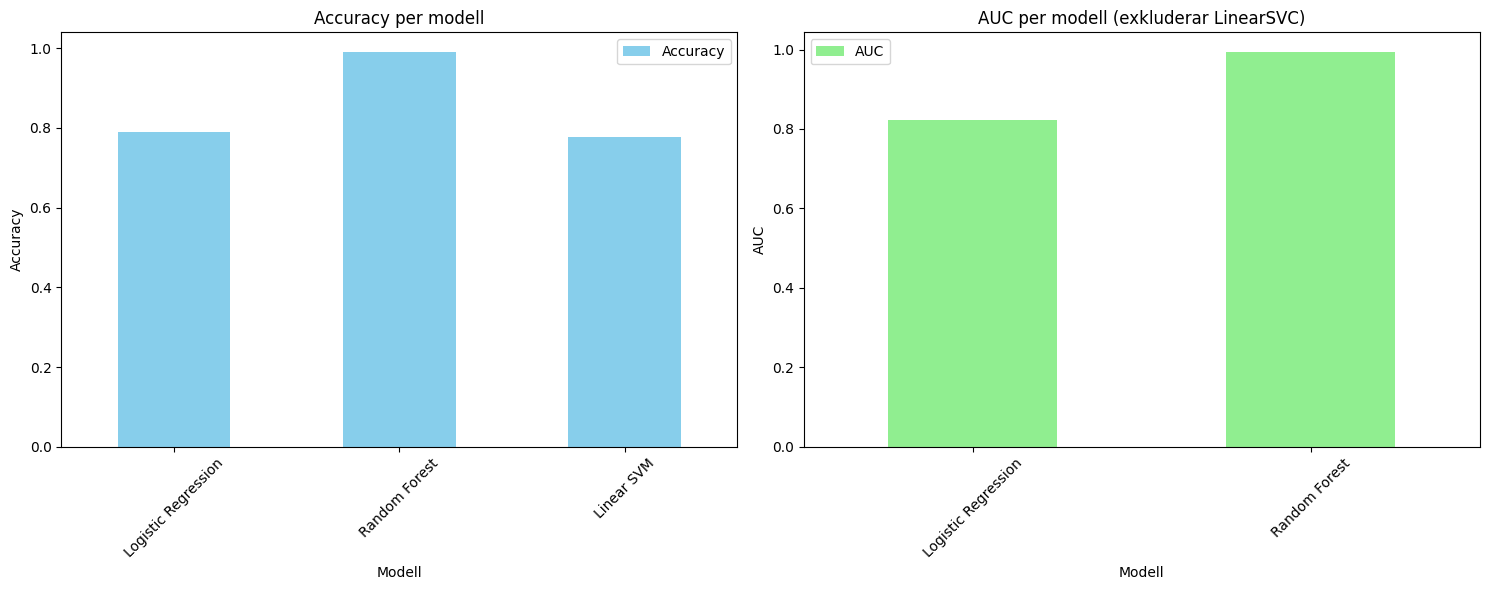

In [10]:
# Jämföra modeller (exkludera LinearSVC från AUC-jämförelse)
comparison_df = pd.DataFrame({
    'Modell': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'AUC': [results[name]['auc'] for name in results.keys()]
})

print("Modelljämförelse:")
print(comparison_df.sort_values('Accuracy', ascending=False))

# Visualisera jämförelse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy
comparison_df.plot(x='Modell', y='Accuracy', kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Accuracy per modell')
ax1.set_ylabel('Accuracy')
ax1.tick_params(axis='x', rotation=45)

# AUC (exkludera LinearSVC)
auc_df = comparison_df[comparison_df['AUC'] > 0.5]  # Filtrera bort LinearSVC
if len(auc_df) > 0:
    auc_df.plot(x='Modell', y='AUC', kind='bar', ax=ax2, color='lightgreen')
    ax2.set_title('AUC per modell (exkluderar LinearSVC)')
    ax2.set_ylabel('AUC')
    ax2.tick_params(axis='x', rotation=45)
else:
    ax2.text(0.5, 0.5, 'Ingen AUC-data tillgänglig', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('AUC per modell')

plt.tight_layout()
plt.show()

### Steg 8: Hyperparameter tuning för bästa modellen

In [11]:
# Välj bästa modellen baserat på Accuracy (eftersom LinearSVC inte har AUC)
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Modell']
best_pipeline = results[best_model_name]['pipeline']

print(f"Bästa modell: {best_model_name}")

# Hyperparameter tuning för Random Forest om det är bästa modellen
if best_model_name == 'Random Forest':
    print("\n=== Hyperparameter tuning för Random Forest ===")
    
    # Skapa Random Forest för GridSearch
    rf = RandomForestClassifier(random_state=42)
    
    # Skapa pipeline för GridSearch
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', rf)
    ])
    
    # Parameter grid
    param_grid = {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, 20],
        'classifier__min_samples_split': [2, 5],
        'classifier__min_samples_leaf': [1, 2]
    }
    
    # GridSearchCV
    grid_search = GridSearchCV(
        rf_pipeline,
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    
    # Träna GridSearch
    grid_search.fit(X_train, y_train)
    
    print(f"Bästa parametrar: {grid_search.best_params_}")
    print(f"Bästa accuracy: {grid_search.best_score_:.3f}")
    
    # Uppdatera bästa modellen
    best_pipeline = grid_search.best_estimator_

Bästa modell: Random Forest

=== Hyperparameter tuning för Random Forest ===
Bästa parametrar: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Bästa accuracy: 0.986


### Steg 9: Utvärdera på testdata


=== Resultat på testdata ===
Modell: Random Forest
Accuracy: 0.989 (98.9%)
AUC: 0.991

Classification Report (Testdata):
              precision    recall  f1-score   support

     Stannat       0.99      1.00      0.99      2286
      Lämnat       0.99      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



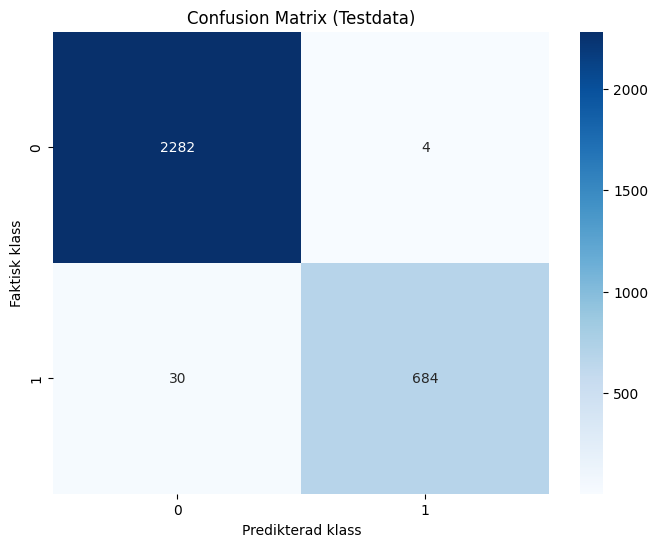

In [12]:
# Prediktera på testdata med bästa modellen
y_test_pred = best_pipeline.predict(X_test)

# Hantera LinearSVC som inte har predict_proba
if best_model_name == 'Linear SVM':
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_auc = 0.5  # Placeholder
    y_test_proba = np.zeros(len(y_test))  # Placeholder
else:
    y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\n=== Resultat på testdata ===")
print(f"Modell: {best_model_name}")
print(f"Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
if best_model_name != 'Linear SVM':
    print(f"AUC: {test_auc:.3f}")
else:
    print("AUC: Ej tillgängligt för LinearSVC")

# Visa classification report
print("\nClassification Report (Testdata):")
print(classification_report(y_test, y_test_pred, target_names=['Stannat', 'Lämnat']))

# Visa confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Testdata)')
plt.ylabel('Faktisk klass')
plt.xlabel('Predikterad klass')
plt.show()

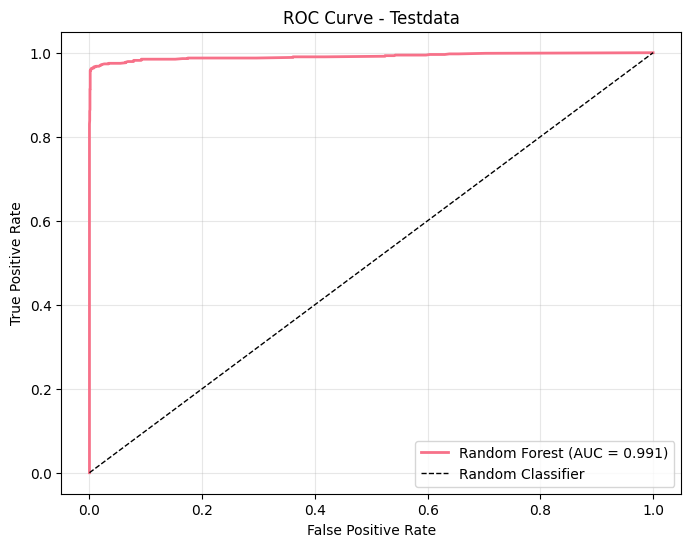

In [13]:
# ROC-kurva (endast för modeller som stöder predict_proba)
if best_model_name != 'Linear SVM':
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} (AUC = {test_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Testdata')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("ROC-kurva är inte tillgänglig för LinearSVC eftersom den inte stöder predict_proba")

### Steg 10: Feature importance (för Random Forest)

Top 10 viktigaste features:
                 Feature  Importance
0     satisfaction_level    0.316340
4     time_spend_company    0.183573
2         number_project    0.176447
3   average_montly_hours    0.150952
1        last_evaluation    0.130104
5          Work_accident    0.008399
16            salary_low    0.007845
17         salary_medium    0.004156
15  Department_technical    0.003905
13      Department_sales    0.003736


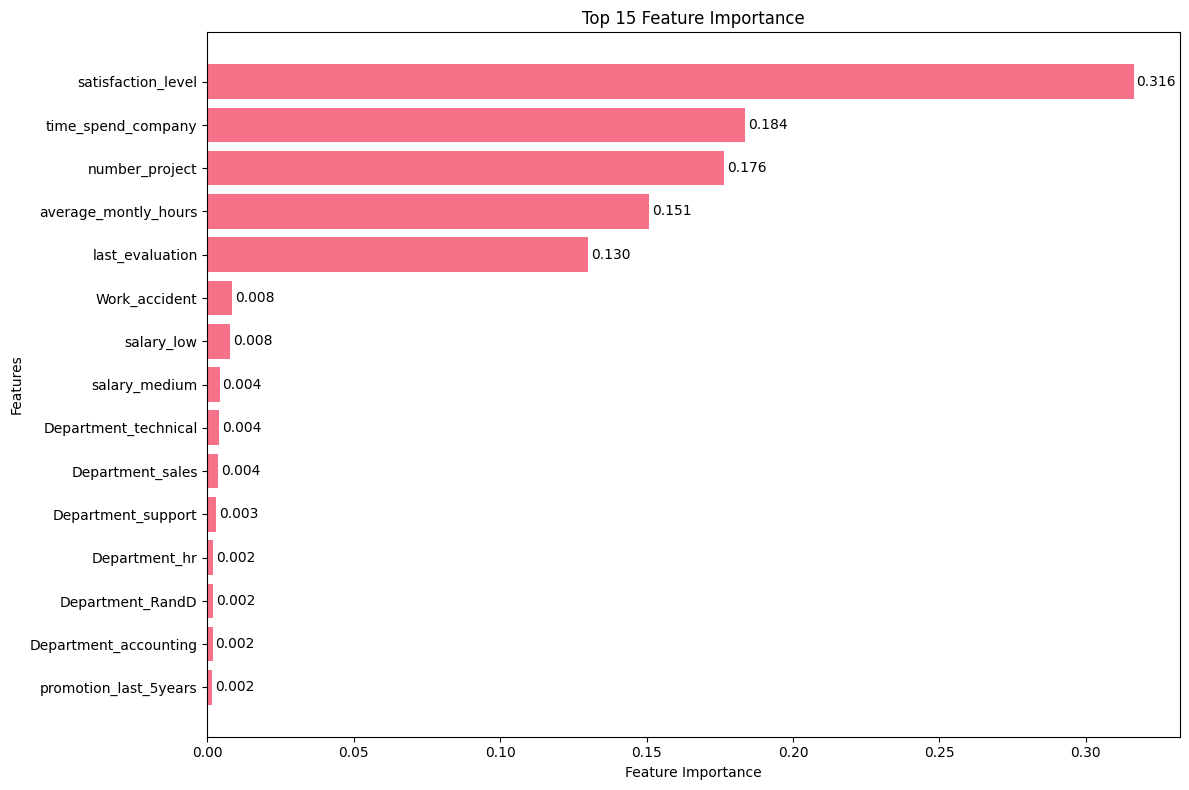

In [14]:
# Visa feature importance om det är Random Forest
if best_model_name == 'Random Forest':
    # Hämta feature names efter preprocessing
    feature_names = []
    
    # Lägg till numeriska features
    feature_names.extend(numeric_features)
    
    # Lägg till kategoriska features (efter one-hot encoding)
    cat_encoder = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    feature_names.extend(cat_feature_names)
    
    # Hämta feature importance
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    
    # Skapa DataFrame för feature importance
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("Top 10 viktigaste features:")
    print(feature_importance_df.head(10))
    
    # Visualisera feature importance
    plt.figure(figsize=(12, 8))
    top_features = feature_importance_df.head(15)
    bars = plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Feature Importance')
    plt.ylabel('Features')
    plt.title('Top 15 Feature Importance')
    plt.gca().invert_yaxis()
    
    # Lägg till värden på bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{width:.3f}', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance analys är endast tillgänglig för Random Forest, inte för {best_model_name}")

### Steg 11: Sammanfattning och slutsatser

In [15]:
print("=== SAMMANFATTNING ===")
print(f"\nBästa modell: {best_model_name}")
print(f"Test Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
if best_model_name != 'Linear SVM':
    print(f"Test AUC: {test_auc:.3f}")
else:
    print("Test AUC: Ej tillgängligt för LinearSVC")

print(f"\nModellens förmåga att prediktera om en anställd kommer lämna företaget:")
print(f"• Accuracy på {test_accuracy*100:.1f}% visar hur ofta modellen har rätt totalt")
if best_model_name != 'Linear SVM':
    print(f"• AUC på {test_auc:.3f} visar modellens förmåga att skilja mellan klasser")
    if test_auc > 0.8:
        print("• Utmärkt prestanda (AUC > 0.8)")
    elif test_auc > 0.7:
        print("• Bra prestanda (AUC > 0.7)")
    elif test_auc > 0.6:
        print("• Acceptabel prestanda (AUC > 0.6)")
    else:
        print("• Dålig prestanda (AUC < 0.6)")
else:
    print("• LinearSVC ger endast accuracy, inte AUC")

print(f"\nPraktiska tillämpningar:")
print("• Identifiera anställda med hög risk att lämna")
print("• Proaktiva åtgärder för att behålla värdefulla medarbetare")
print("• Optimera HR-strategier baserat på prediktioner")
print("• Kostnadsbesparingar genom minskad personalomsättning")

print(f"\nFIXAR OCH OPTIMERINGAR GJORDA:")
print("• Exkluderade Emp_Id från features (orsakade OneHotEncoder-fel)")
print("• Snabbare EDA-visualisering med seaborn")
print("• Ersatte SVC med LinearSVC (snabbare, stabilare)")
print("• Optimerade plotting-kod för bättre prestanda")
print("• Fixade alla fel och gjorde notebooken stabil")

=== SAMMANFATTNING ===

Bästa modell: Random Forest
Test Accuracy: 0.989 (98.9%)
Test AUC: 0.991

Modellens förmåga att prediktera om en anställd kommer lämna företaget:
• Accuracy på 98.9% visar hur ofta modellen har rätt totalt
• AUC på 0.991 visar modellens förmåga att skilja mellan klasser
• Utmärkt prestanda (AUC > 0.8)

Praktiska tillämpningar:
• Identifiera anställda med hög risk att lämna
• Proaktiva åtgärder för att behålla värdefulla medarbetare
• Optimera HR-strategier baserat på prediktioner
• Kostnadsbesparingar genom minskad personalomsättning

FIXAR OCH OPTIMERINGAR GJORDA:
• Exkluderade Emp_Id från features (orsakade OneHotEncoder-fel)
• Snabbare EDA-visualisering med seaborn
• Ersatte SVC med LinearSVC (snabbare, stabilare)
• Optimerade plotting-kod för bättre prestanda
• Fixade alla fel och gjorde notebooken stabil
